# Google Stock Price Prediction using RNN

This notebook implements a time series analysis and prediction system for Google stock prices using Recurrent Neural Networks (RNN).

## Problem Statement:

Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

## Dataset Description

The dataset consists of Google (GOOGL) stock price data with the following characteristics:
- Historical daily price data for 5 years
- Each record contains: Open, High, Low, Close, Volume, and Dividends
- Data source: Yahoo Finance API (yfinance)

### Features
| Feature | Description |
|---------|-------------|
| Open | Price at market open |
| High | Highest price during the day |
| Low | Lowest price during the day |
| Close | Price at market close |
| Volume | Number of shares traded |
| Dividends | Dividend payments |

### Data Preprocessing
- Sequence length: 60 days (used for prediction)
- Training/Testing split: 80%/20%
- Feature scaling: MinMaxScaler
- Target variable: Close price

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_style('whitegrid')

I0000 00:00:1776747057.607624   69845 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776747057.691365   69845 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776747059.468830   69845 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Download Google stock data
google = yf.Ticker('GOOGL')
df = google.history(period='5y')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (1255, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-04-21 00:00:00-04:00,112.671276,113.065516,111.320933,112.983696,23204000,0.0,0.0
2021-04-22 00:00:00-04:00,112.837394,113.505872,111.097774,111.702774,24146000,0.0,0.0
2021-04-23 00:00:00-04:00,112.420845,114.360813,112.135704,114.053848,29066000,0.0,0.0
2021-04-26 00:00:00-04:00,114.281468,115.273771,113.924419,114.549751,32038000,0.0,0.0
2021-04-27 00:00:00-04:00,114.931590,114.972254,113.370987,113.610016,44386000,0.0,0.0


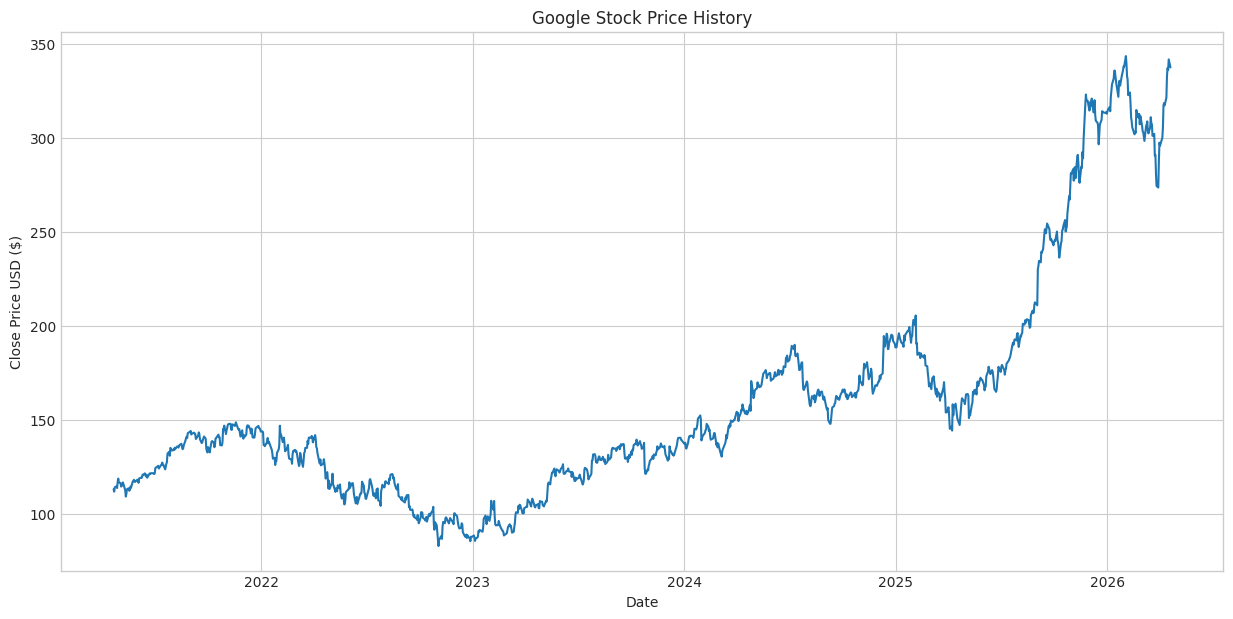

In [3]:
# Plot the closing price history
plt.figure(figsize=(15,7))
plt.title('Google Stock Price History')
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.show()

In [4]:
# Prepare the data for training
data = df['Close'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences for training
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Define sequence length (number of time steps)
seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [5]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

E0000 00:00:1776747063.139101   69845 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/opt/my_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0075 - val_loss: 0.0023
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0012 - val_loss: 0.0028
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 9.5892e-04 - val_loss: 0.0013
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 9.0826e-04 - val_loss: 0.0013
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 9.1527e-04 - val_loss: 0.0018
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 9.5849e-04 - val_loss: 0.0012
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 9.6790e-04 - val_loss: 0.0012
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 8.7336e-04 - val_loss: 9.6176e-04
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 8.4243e-04 - val_loss: 9.3980e-04
Epoch 12/50
27/27

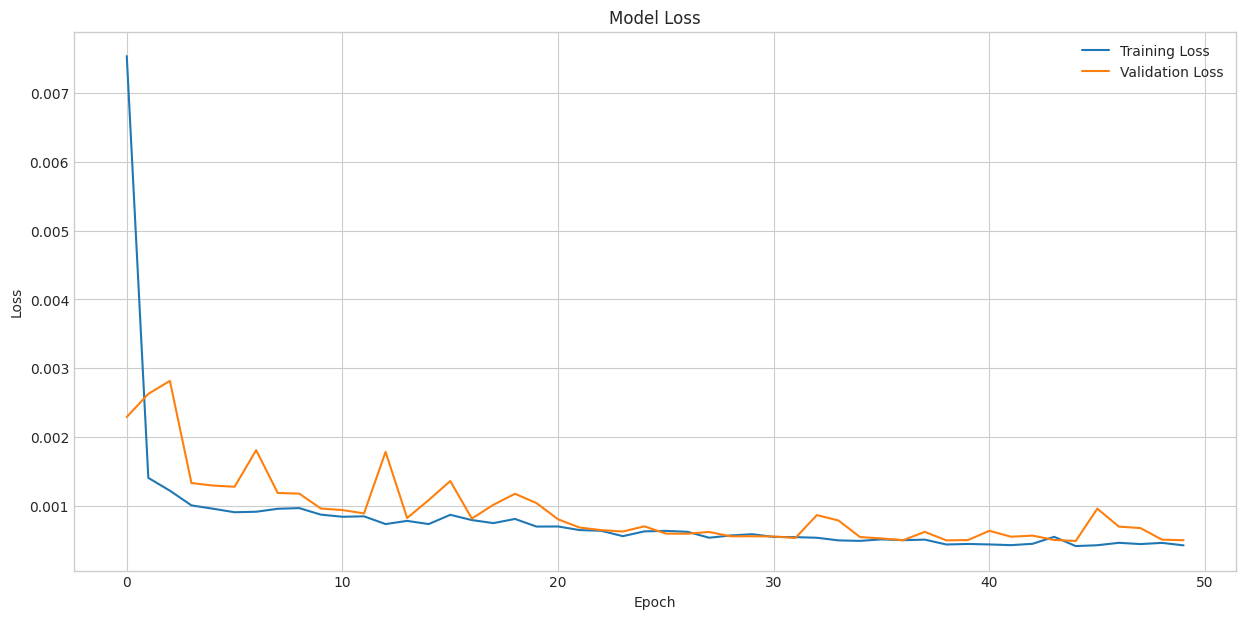

In [7]:
# Plot training history
plt.figure(figsize=(15,7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train)
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test)

# Calculate RMSE
train_rmse = np.sqrt(np.mean((train_predict - y_train_inv) ** 2))
test_rmse = np.sqrt(np.mean((test_predict - y_test_inv) ** 2))
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Train RMSE: 4.45
Test RMSE: 9.11


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

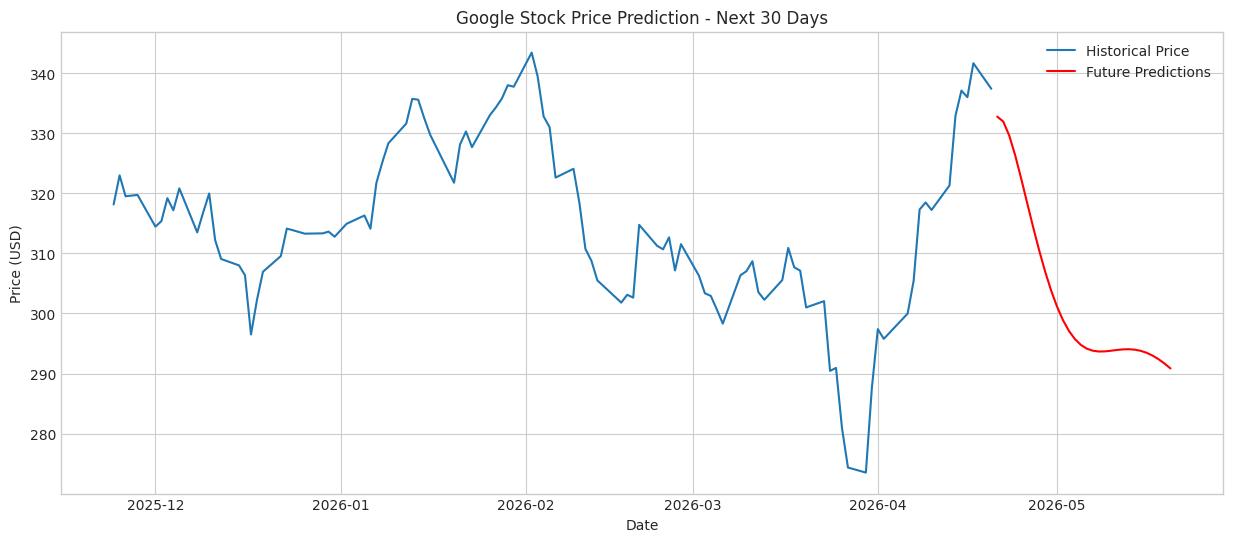


Predicted prices for the next 5 days:
2026-04-21: $332.78
2026-04-22: $331.97
2026-04-23: $329.65
2026-04-24: $326.34
2026-04-25: $322.49


In [9]:
def predict_future(model, last_sequence, n_steps):
    """Predict future values using the trained model."""
    future_predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(n_steps):
        # Get prediction for next day
        next_pred = model.predict(current_sequence.reshape(1, seq_length, 1))[0]
        future_predictions.append(next_pred)
        
        # Update sequence for next prediction
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = next_pred
    
    return np.array(future_predictions)

# Get last sequence from data
last_sequence = scaled_data[-seq_length:]

# Predict next 30 days
future_pred_scaled = predict_future(model, last_sequence, 30)
future_pred = scaler.inverse_transform(future_pred_scaled)

# Create future dates
last_date = df.index[-1]
future_dates = [last_date + timedelta(days=x) for x in range(1, 31)]

# Plot predictions including historical data
plt.figure(figsize=(15, 6))
plt.plot(df.index[-100:], df['Close'].values[-100:], label='Historical Price')
plt.plot(future_dates, future_pred, label='Future Predictions', color='red')
plt.title('Google Stock Price Prediction - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Print predicted prices
print("\nPredicted prices for the next 5 days:")
for date, price in zip(future_dates[:5], future_pred[:5]):
    print(f"{date.strftime('%Y-%m-%d')}: ${price[0]:.2f}")